In [1]:
import torch
import matplotlib.pyplot as plt
import mhnlib.utils as mhn_utils

### Whatever

In [2]:
torch.manual_seed(1101252)

# ------------------------------------------------------------
# Euclidean modern Hopfield network
# ------------------------------------------------------------

N = 2
R = 32

num_ics = 30000
num_steps = 10000
num_betas = 200
dt = 0.01

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
#device = "cpu"
dtype = torch.float32

# Patterns / centroids: shape (R, N)
centroids = torch.randn(
    R,
    N,
    device=device,
    dtype=dtype,
)

# Optional: put all centroids on the unit sphere
#centroids = centroids / centroids.norm(
#    dim=-1,
#    keepdim=True,
#).clamp_min(1e-12)

betas = torch.logspace(
    0,
    1,
    steps=num_betas,
    device=device,
    dtype=dtype,
)

# Use the same initial conditions for every beta
x0 = torch.randn(
    1,
    num_ics,
    N,
    device=device,
    dtype=dtype,
)

# x.shape = (num_betas, num_ics, N)
x = x0.expand(num_betas, -1, -1).clone()

# Component-dependent constant in
# -1/2 ||x - mu_r||² = mu_rᵀx - 1/2 ||mu_r||² - 1/2 ||x||²
centroid_bias = -0.5 * centroids.square().sum(dim=-1)

with torch.no_grad():
    for step in range(num_steps):
        # mu_r^T x
        # shape: (num_betas, num_ics, R)
        overlaps = torch.einsum(
            "bcn,rn->bcr",
            x,
            centroids,
        )

        # The common term -beta ||x||² / 2 cancels in the softmax
        logits = betas[:, None, None] * (
            overlaps
            + centroid_bias[None, None, :]
        )

        weights = torch.softmax(logits, dim=-1)

        # Weighted centroid:
        # sum_r w_r mu_r
        mean_field = torch.einsum(
            "bcr,rn->bcn",
            weights,
            centroids,
        )

        # Semi-implicit update for:
        # dx/dt = mean_field(x) - x
        x = (x + dt * mean_field) / (1.0 + dt)

# Final states:
# x.shape == (num_betas, num_ics, N)

# Final pattern probabilities
with torch.no_grad():
    overlaps = torch.einsum(
        "bcn,rn->bcr",
        x,
        centroids,
    )

    logits = betas[:, None, None] * (
        overlaps
        + centroid_bias[None, None, :]
    )

    weights = torch.softmax(logits, dim=-1)

# Retrieved pattern index for each beta and initial condition
retrieved_patterns = weights.argmax(dim=-1)

print("x shape:", x.shape)
print("weights shape:", weights.shape)
print("finite:", torch.isfinite(x).all().item())
print("maximum final norm:", x.norm(dim=-1).max().item())

x = x.cpu()
weights = weights.cpu()
retrieved_patterns = retrieved_patterns.cpu()
betas = betas.cpu()
centroids = centroids.cpu()

x shape: torch.Size([200, 30000, 2])
weights shape: torch.Size([200, 30000, 32])
finite: True
maximum final norm: 2.9858081340789795


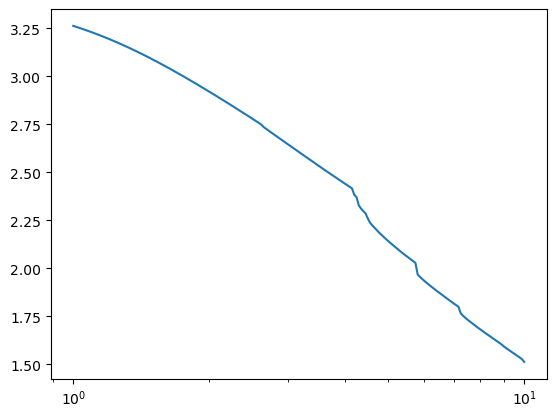

In [3]:
plt.plot(betas, mhn_utils.get_entropy(weights).mean(dim=-1))
plt.xscale("log")

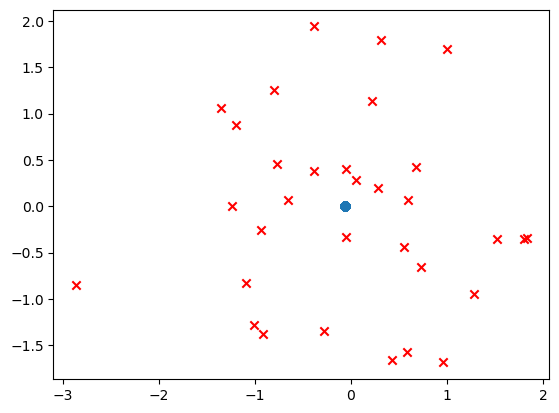

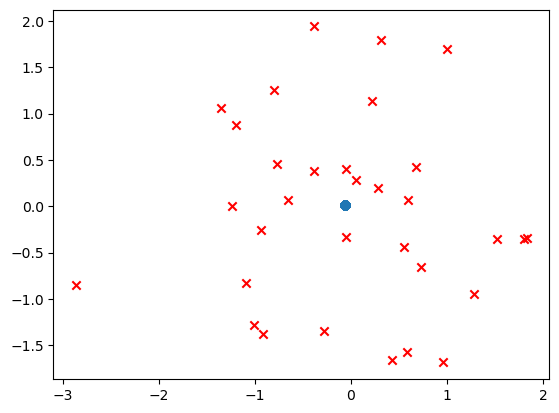

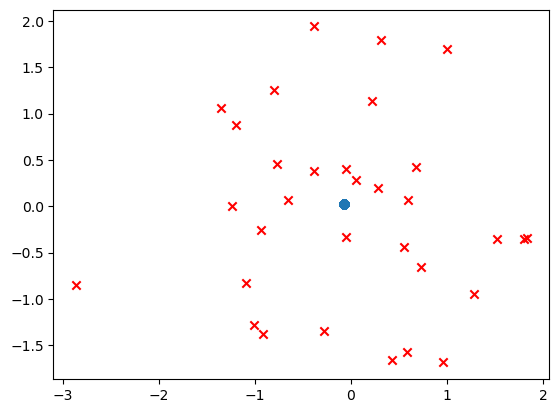

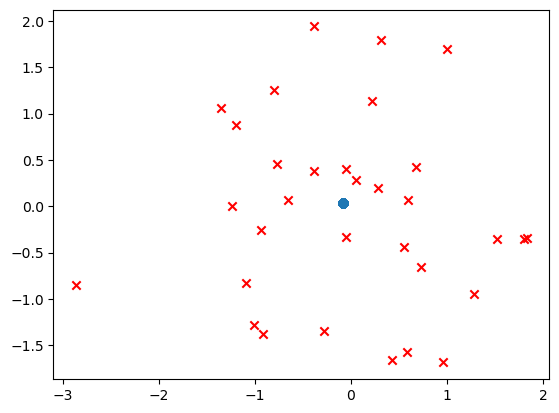

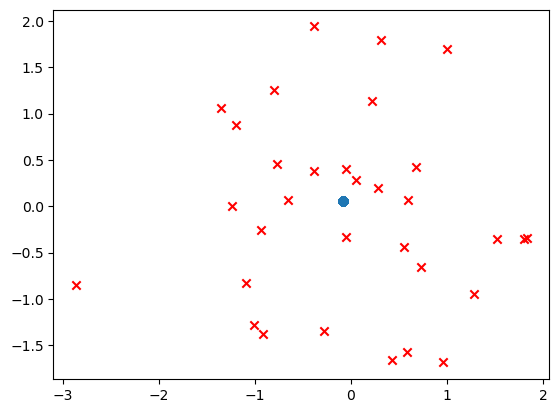

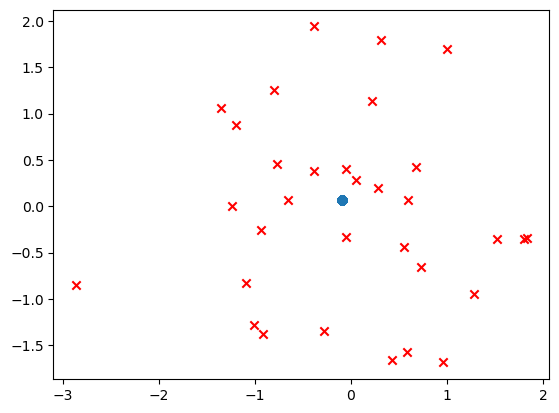

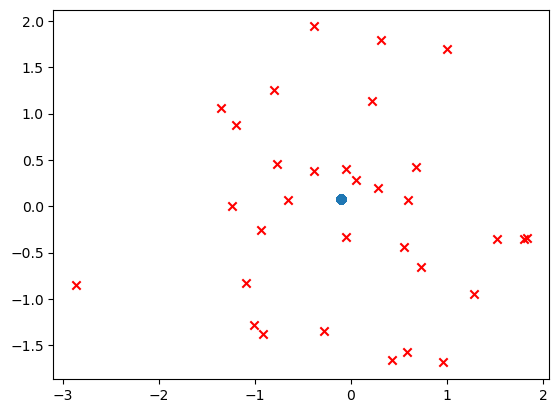

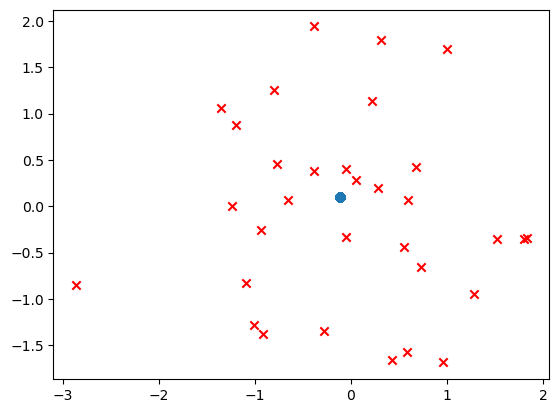

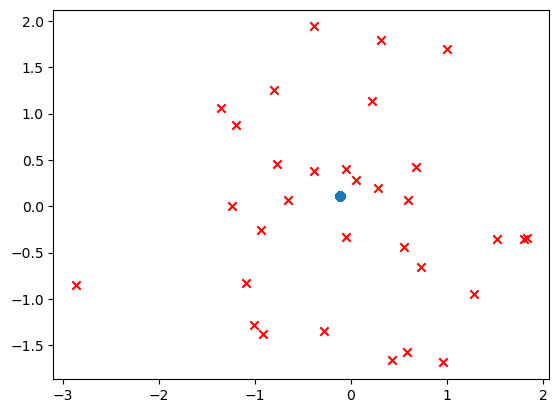

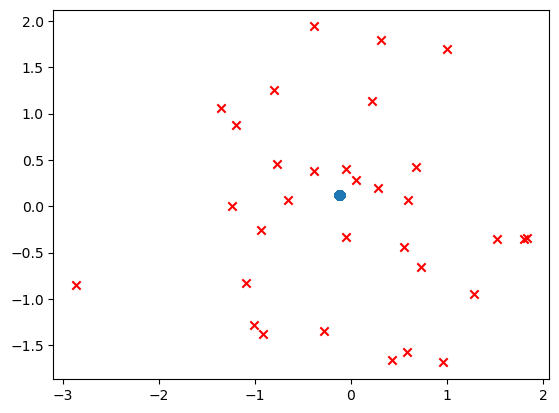

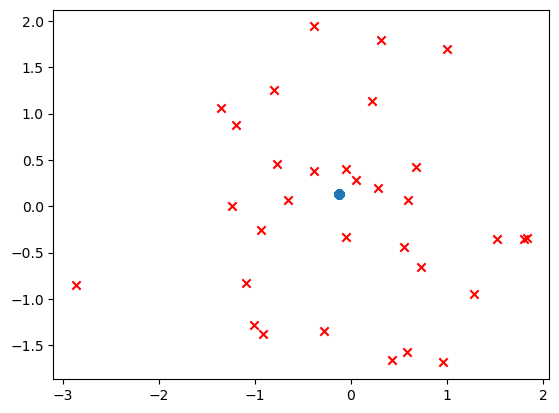

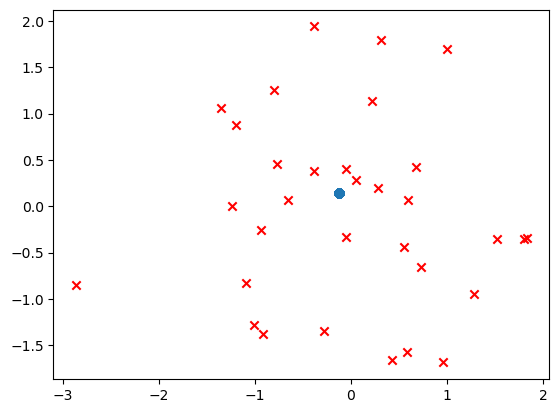

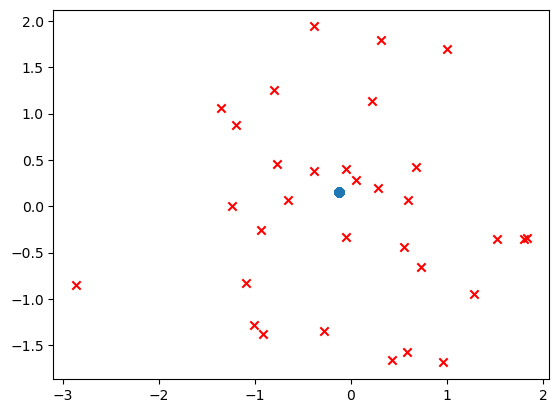

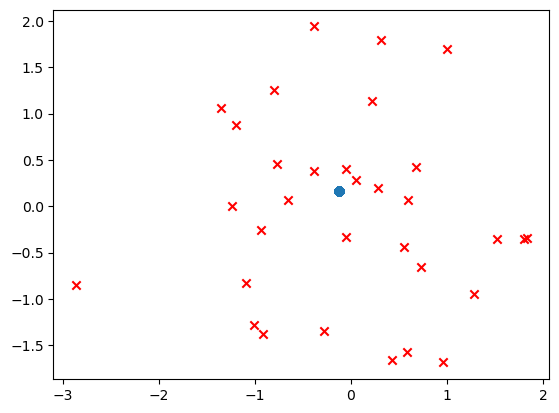

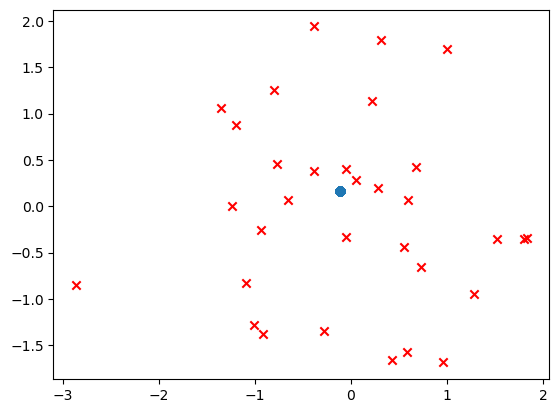

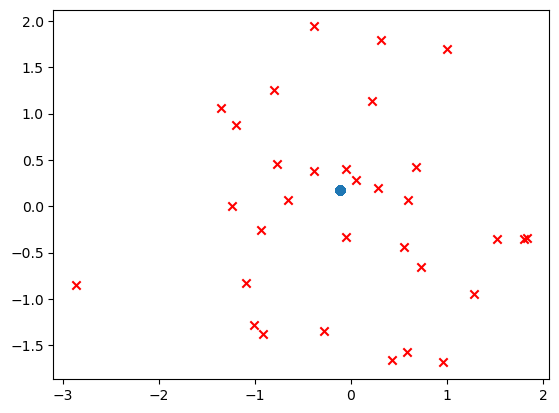

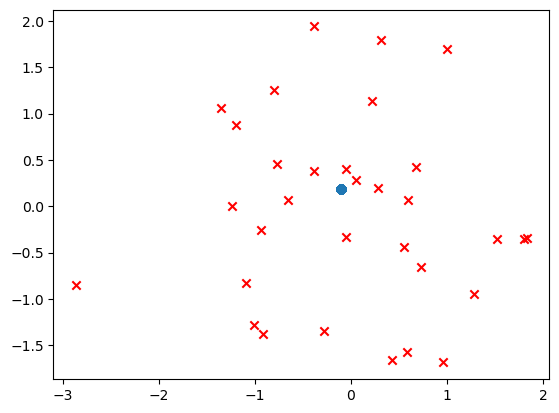

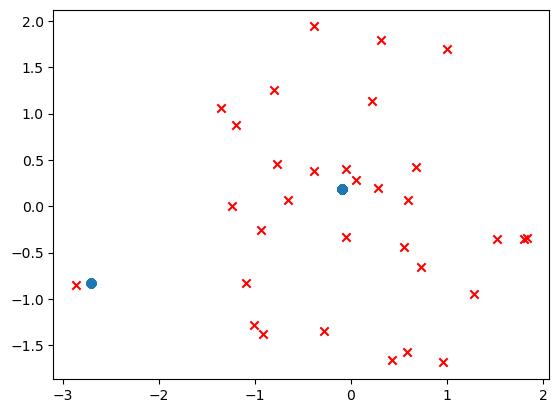

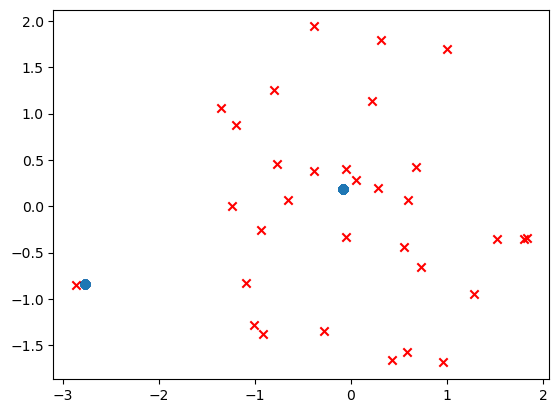

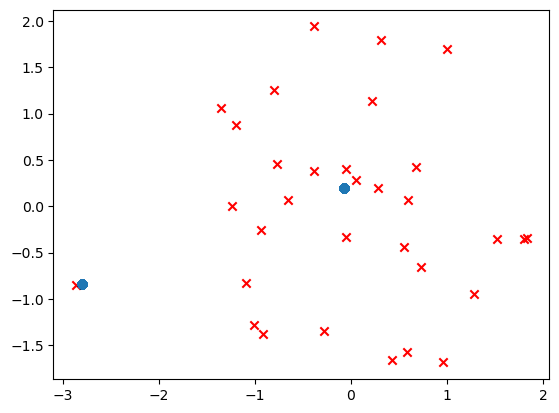

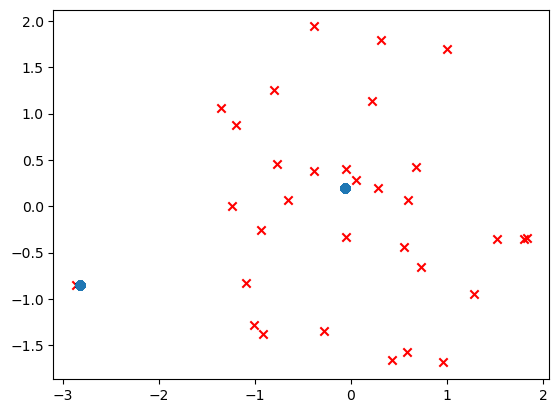

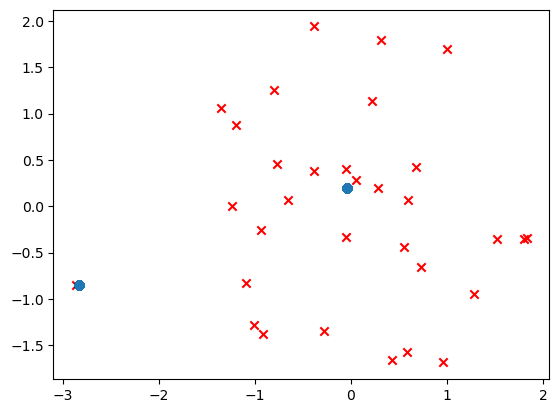

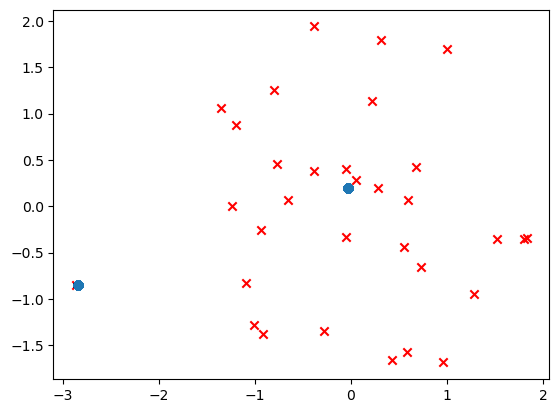

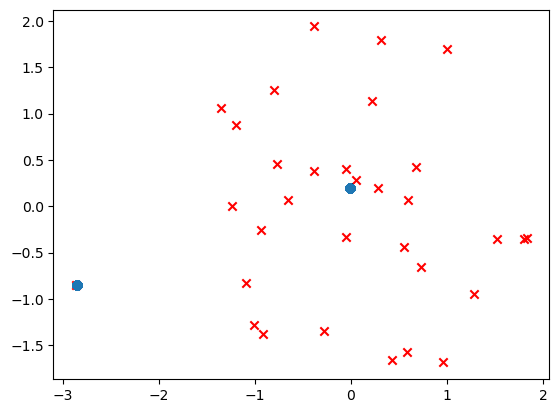

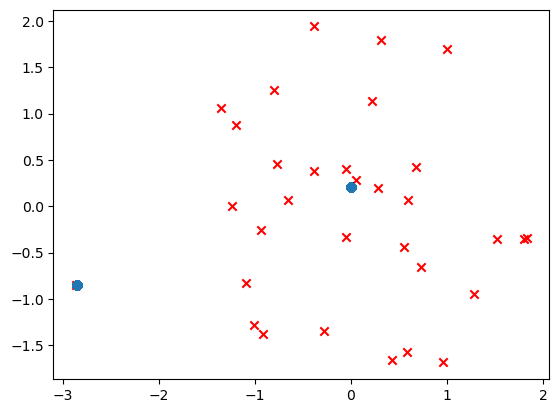

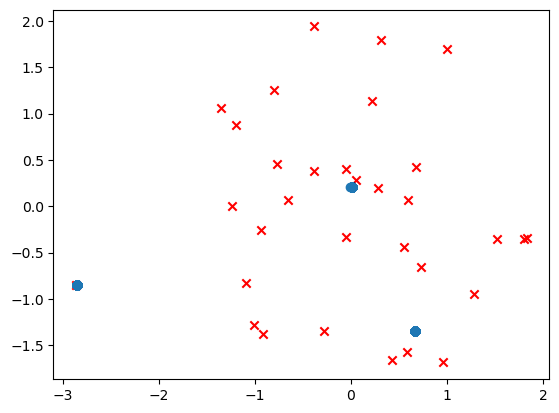

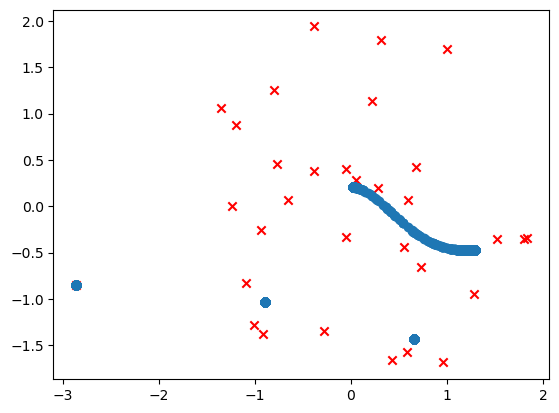

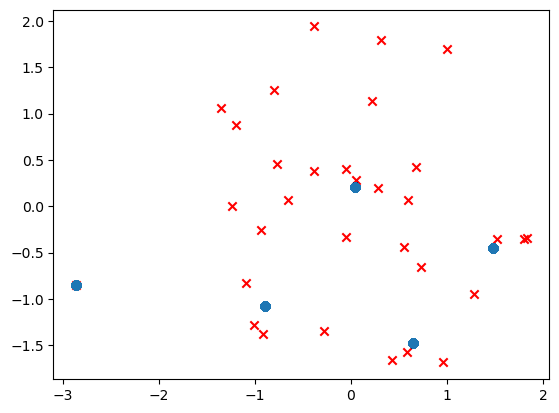

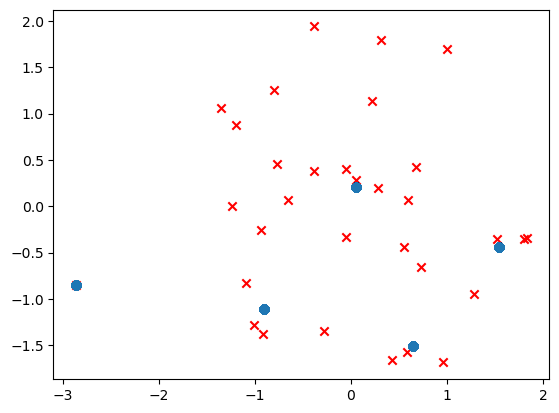

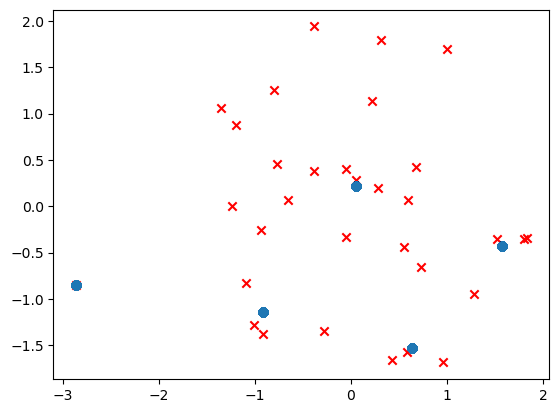

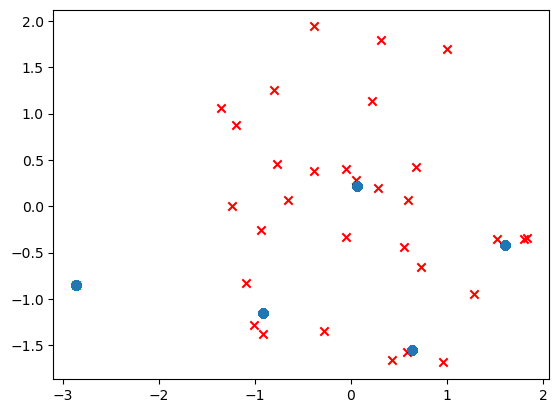

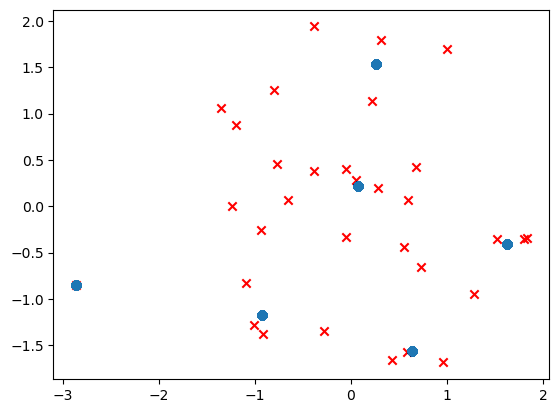

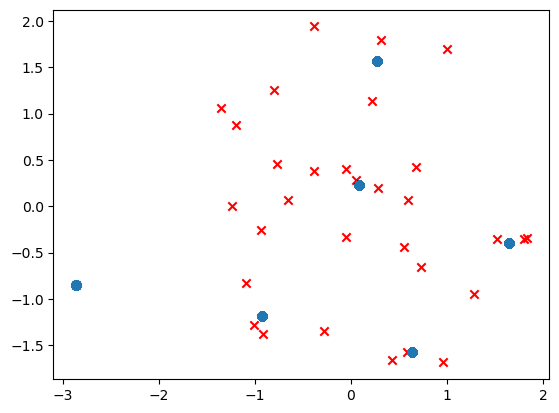

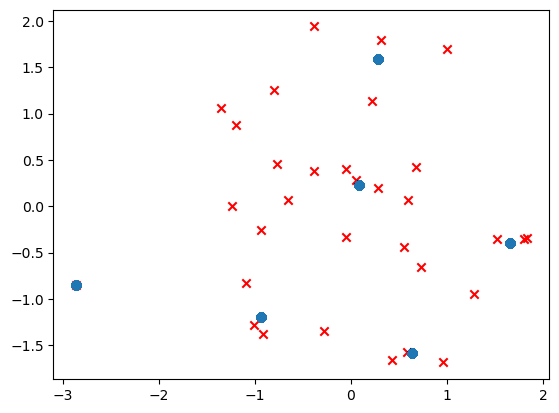

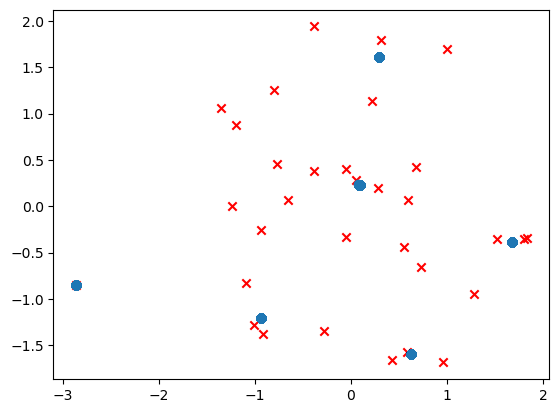

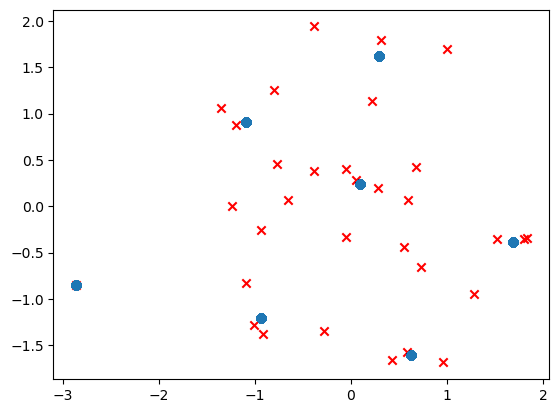

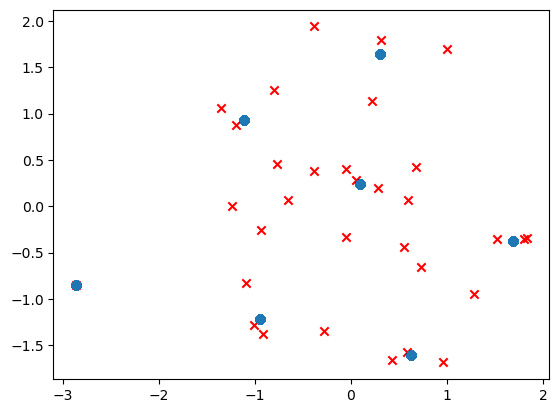

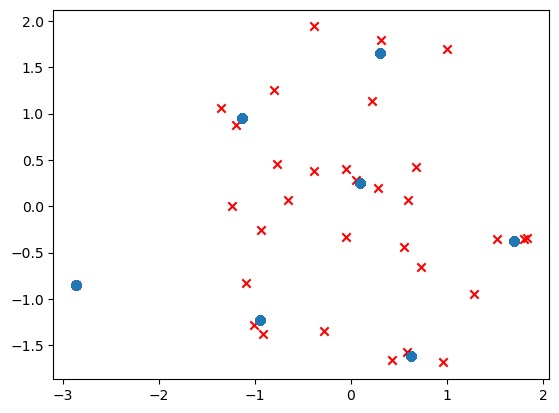

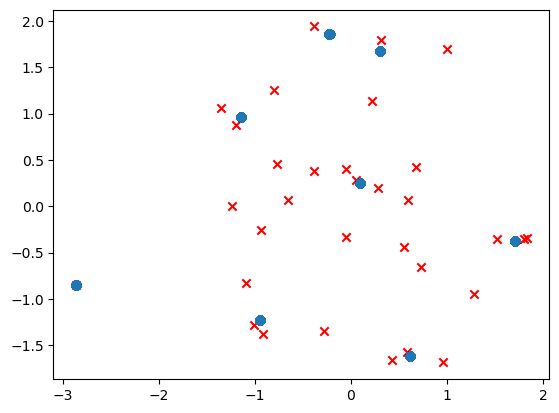

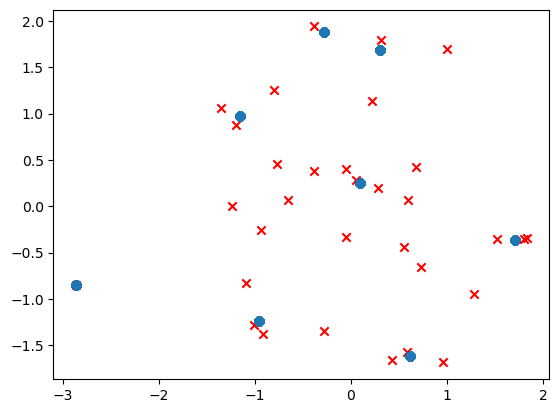

In [4]:
for i in range(0,num_betas,5):
    plt.scatter(centroids[:,0], centroids[:,1], marker='x', color='red')
    plt.scatter(x[i,:,0], x[i,:,1])
    plt.show()